# Pha U — S1: thăm dò thích nghi miền trên dữ liệu thật (nhánh `phase-u-domain-adaptation`)

**Vấn đề:** mạng học sẵn (huấn luyện trên dữ liệu mô phỏng) fail trên dữ liệu tim–hô hấp thật (TE hô hấp→tim = -0.247, sai hướng); dữ liệu thật nằm ngoài vùng biểu diễn của mạng.

**Ý tưởng:** chặn dưới DV **không cần nhãn TE**, nên tinh chỉnh mạng bằng chính cửa sổ thật (cả 2 chiều, DV loss, lr nhỏ, ít epoch).

**Chống rò rỉ (bắt buộc):** k-fold **theo bản ghi** — mỗi bản ghi chỉ được đánh giá bởi mô hình chưa từng thấy cửa sổ nào của nó. Không có TE thật trên dữ liệu thật, nên đo 3 thứ: (1) chiều TE có đúng RSA (hô hấp→tim > tim→hô hấp) không, (2) tương quan theo bản ghi với KSG, (3) khoảng tin cậy/Wilcoxon theo bản ghi.

**Điểm dừng G1** (in ở cell cuối): thích nghi phải cải thiện RÕ cả chiều lẫn đồng thuận với KSG so với chưa thích nghi, nếu không thì dừng hướng này.

Ước tính chạy: ~40–60 phút.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from pathlib import Path
from scipy.stats import spearmanr

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
from pqrst.estimators.mine.adapt import adapt_amortized, make_record_folds
from pqrst.baselines.ksg import KSGTEEstimator
from pqrst.evaluation.sanity_check import bidirectional_te_per_record, run_sanity_check_per_record

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'real'/'preprocessing.yaml', encoding='utf-8'))

K_FOLDS = 4
LRS = [1e-4, 1e-3]   # KHAI BAO TRUOC 2 muc lr (khong chinh them sau khi thay ket qua); bao cao CA HAI
EPOCHS = 5
CAP_PER_RECORD_DIR = 100   # so cua so toi da / ban ghi / chieu dung de thich nghi (gioi han thoi gian)
SEED = 0

## 1. Nạp các bản ghi Fantasia đã PASS (giống Pha S)

In [2]:
proc_dir = BASE/'data'/'processed'/'fantasia'
quality = pd.read_csv(proc_dir/'quality_report.csv')
passed = quality.loc[quality['verdict']=='PASS','record_id'].tolist()
records = {}
for rid in passed:
    w_rr_to_resp = load_corpus(str(proc_dir/(rid+'_fwd.npz')))
    w_resp_to_rr = load_corpus(str(proc_dir/(rid+'_bwd.npz')))
    records[rid] = (w_resp_to_rr, w_rr_to_resp)   # (forward: resp->tim, backward: tim->resp)
print(len(records), 'ban ghi:', passed)
print('So cua so / ban ghi (1 chieu):', {r: len(v[0]) for r,v in list(records.items())[:5]}, '...')

17 ban ghi: ['f1o09', 'f1y01', 'f1y02', 'f1y04', 'f1y05', 'f1y06', 'f1y07', 'f1y08', 'f1y09', 'f1y10', 'f2o06', 'f2o07', 'f2y01', 'f2y06', 'f2y07', 'f2y08', 'f2y09']
So cua so / ban ghi (1 chieu): {'f1o09': 241, 'f1y01': 240, 'f1y02': 241, 'f1y04': 241, 'f1y05': 243} ...


## 2. Baseline: KSG và mạng CHƯA thích nghi (theo bản ghi)

In [3]:
base = AmortizedTEEstimator.load(str(BASE/'results'/'checkpoints'/'phi_amortized_standardized.pt'))
assert base.config.standardize
t0=time.time()
per_rec = {
    'KSG': bidirectional_te_per_record(records, KSGTEEstimator()),
    'Unadapted': bidirectional_te_per_record(records, base),
}
print(f'{time.time()-t0:.0f}s')
pd.DataFrame({k:{r:v['te_forward']-v['te_backward'] for r,v in d.items()} for k,d in per_rec.items()}).round(4)

403s


,KSG,Unadapted
f1o09,-0.0184,-0.0263
f1y01,0.0247,-0.2372
f1y02,0.0077,-0.2320
f1y04,-0.0135,-0.2755
f1y05,0.0428,-0.2004
f1y06,0.0194,-0.1278
f1y07,0.0095,-0.1010
f1y08,0.0053,-0.0840
f1y09,0.0277,-0.1607
f1y10,0.0086,-0.1561


## 3. Thích nghi theo k-fold TRÊN BẢN GHI (không rò rỉ)

In [4]:
folds = make_record_folds(list(records), K_FOLDS, seed=SEED)
print('Folds:', folds)

def sample(ws, n, rng):
    if len(ws) <= n: return list(ws)
    idx = rng.choice(len(ws), n, replace=False)
    return [ws[i] for i in idx]

for LR in LRS:
    name = f'Adapted_lr{LR:g}'
    rng = np.random.default_rng(SEED)
    adapted_per_rec = {}
    for fi, held in enumerate(folds):
        train_ids = [r for r in records if r not in held]
        val_id, adapt_ids = train_ids[0], train_ids[1:]      # 1 ban ghi train lam val (KHONG phai ban ghi giu lai)
        adapt_w = [w for r in adapt_ids for d in (0,1) for w in sample(records[r][d], CAP_PER_RECORD_DIR, rng)]
        val_w = [w for d in (0,1) for w in sample(records[val_id][d], 40, rng)]
        t0=time.time()
        est_ad, hist = adapt_amortized(base, adapt_w, val_w, learning_rate=LR, max_epochs=EPOCHS, seed=SEED+fi)
        adapted_per_rec.update(bidirectional_te_per_record({r: records[r] for r in held}, est_ad))
        print(f'{name} fold {fi}: giu lai {held} | adapt={len(adapt_w)} cua so | val_loss {hist["val_loss_history"][0]:.4f}->{hist["val_loss_history"][-1]:.4f} | {time.time()-t0:.0f}s')
    per_rec[name] = adapted_per_rec

Folds: [['f1y02', 'f1o09', 'f2y09', 'f1y10', 'f2y08'], ['f2o06', 'f1y05', 'f2y01', 'f2y07'], ['f1y04', 'f1y08', 'f2y06', 'f1y09'], ['f2o07', 'f1y06', 'f1y07', 'f1y01']]
Adapted_lr0.0001 fold 0: giu lai ['f1y02', 'f1o09', 'f2y09', 'f1y10', 'f2y08'] | adapt=2200 cua so | val_loss -0.4543->-0.7583 | 194s
Adapted_lr0.0001 fold 1: giu lai ['f2o06', 'f1y05', 'f2y01', 'f2y07'] | adapt=2400 cua so | val_loss -0.4765->-0.8656 | 190s
Adapted_lr0.0001 fold 2: giu lai ['f1y04', 'f1y08', 'f2y06', 'f1y09'] | adapt=2400 cua so | val_loss -0.4781->-0.8788 | 125s
Adapted_lr0.0001 fold 3: giu lai ['f2o07', 'f1y06', 'f1y07', 'f1y01'] | adapt=2400 cua so | val_loss -0.4732->-0.8629 | 133s
Adapted_lr0.001 fold 0: giu lai ['f1y02', 'f1o09', 'f2y09', 'f1y10', 'f2y08'] | adapt=2200 cua so | val_loss -0.7964->-0.8722 | 177s
Adapted_lr0.001 fold 1: giu lai ['f2o06', 'f1y05', 'f2y01', 'f2y07'] | adapt=2400 cua so | val_loss -0.9525->-0.9218 | 177s
Adapted_lr0.001 fold 2: giu lai ['f1y04', 'f1y08', 'f2y06', 'f1y0

## 4. So sánh theo bản ghi (đơn vị mẫu = bản ghi)

In [5]:
rows=[]; diffs={}
ids=list(records)
METHODS = ['KSG','Unadapted'] + [f'Adapted_lr{l:g}' for l in LRS]
for name in METHODS:
    d = per_rec[name]
    fwd=[d[r]['te_forward'] for r in ids]; bwd=[d[r]['te_backward'] for r in ids]
    res = run_sanity_check_per_record(fwd, bwd, n_bootstrap=cfg['n_bootstrap'], seed=cfg['seed'])
    diffs[name]=np.array(fwd)-np.array(bwd)
    rows.append(dict(method=name, n=len(ids), te_resp2heart=np.mean(fwd), te_heart2resp=np.mean(bwd),
        mean_diff=diffs[name].mean(), ci_low=res['ci_difference'][0], ci_high=res['ci_difference'][1],
        wilcoxon_p=res['wilcoxon_p'], frac_correct_dir=(diffs[name]>0).mean()))
summary=pd.DataFrame(rows).round(4)
for name in METHODS[1:]:
    r,p = spearmanr(diffs[name], diffs['KSG'])
    summary.loc[summary.method==name,'spearman_vs_KSG']=round(r,3)
summary.to_csv(BASE/'results'/'tables'/'phase_u_adaptation_probe.csv', index=False)
summary

Sanity check (theo ban ghi, N=17) PASSED: TE forward > TE backward ro ret, CI hieu so khong chua 0, Wilcoxon p=0.0116.
Sanity check (theo ban ghi, N=17) FAILED.
Sanity check (theo ban ghi, N=17) FAILED.
Sanity check (theo ban ghi, N=17) PASSED: TE forward > TE backward ro ret, CI hieu so khong chua 0, Wilcoxon p=0.0000.


,method,n,te_resp2heart,te_heart2resp,mean_diff,ci_low,ci_high,wilcoxon_p,frac_correct_dir,spearman_vs_KSG
0,KSG,17,0.1109,0.0929,0.0180,0.0039,0.0353,0.0116,0.8235,NaN
1,Unadapted,17,-0.2474,-0.0704,-0.1770,-0.2119,-0.1434,1.0000,0.0000,-0.208
2,Adapted_lr0.0001,17,-0.1116,0.0420,-0.1536,-0.1842,-0.1229,1.0000,0.0000,-0.184
3,Adapted_lr0.001,17,0.0374,-0.0102,0.0477,0.0372,0.0585,0.0000,1.0000,-0.017


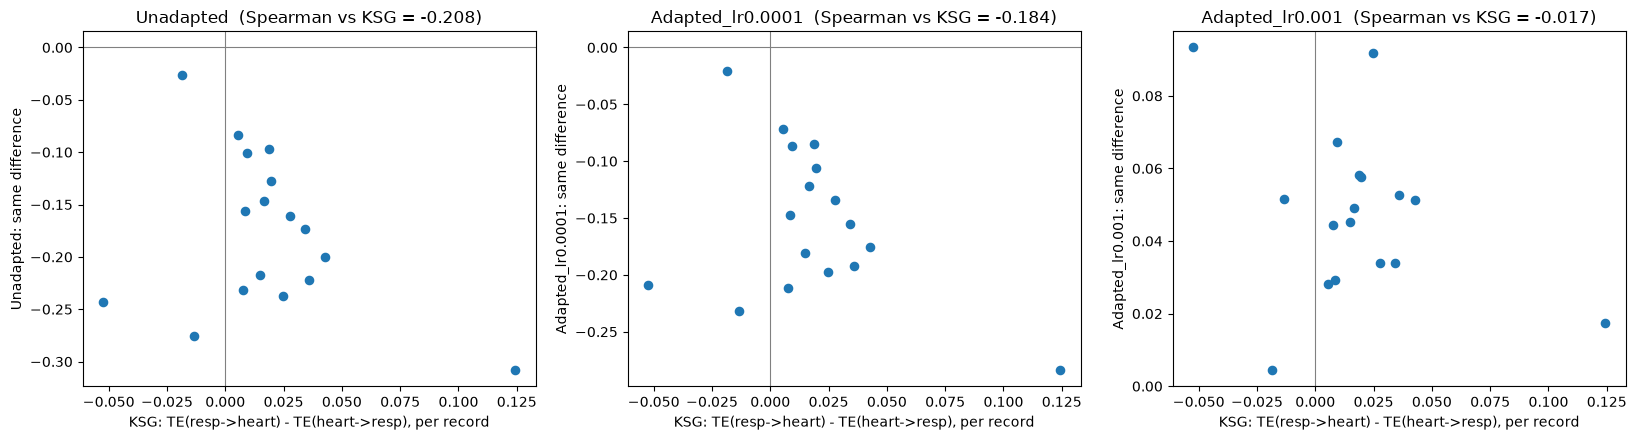

In [6]:
fig,axes=plt.subplots(1,len(METHODS)-1,figsize=(5.5*(len(METHODS)-1),4.5))
for ax,name in zip(axes,METHODS[1:]):
    ax.scatter(diffs['KSG'], diffs[name], s=35)
    ax.axhline(0,c='gray',lw=.8); ax.axvline(0,c='gray',lw=.8)
    ax.set_xlabel('KSG: TE(resp->heart) - TE(heart->resp), per record')
    ax.set_ylabel(f'{name}: same difference')
    ax.set_title(f'{name}  (Spearman vs KSG = {summary.loc[summary.method==name,"spearman_vs_KSG"].values[0]})')
plt.tight_layout(); plt.savefig(BASE/'results'/'figures'/'phase_u_adaptation_probe.png', dpi=110); plt.show()

## 5. Điểm dừng G1 (tính từ số liệu)

In [7]:
u = summary.set_index('method')
print('Da khai bao truoc 2 muc lr => G1 xet cho TUNG muc; neu chi 1 muc qua, coi la bang chung yeu (da thu 2 cau hinh).')
for name in METHODS[2:]:
    dir_gain  = u.loc[name,'frac_correct_dir'] - u.loc['Unadapted','frac_correct_dir']
    corr_gain = u.loc[name,'spearman_vs_KSG'] - u.loc['Unadapted','spearman_vs_KSG']
    pos = u.loc[name,'mean_diff'] > 0
    print(f"\n[{name}] dung chieu RSA: {u.loc['Unadapted','frac_correct_dir']:.2f} -> {u.loc[name,'frac_correct_dir']:.2f} ({dir_gain:+.2f}); "
          f"Spearman vs KSG: {u.loc['Unadapted','spearman_vs_KSG']:.3f} -> {u.loc[name,'spearman_vs_KSG']:.3f} ({corr_gain:+.3f}); "
          f"chenh TB>0: {pos}; CI=[{u.loc[name,'ci_low']:.4f},{u.loc[name,'ci_high']:.4f}]")
    print('   G1:', 'QUA' if (dir_gain >= 0.15 and corr_gain >= 0.15 and pos) else 'CHUA QUA')
print('\nChi 1 lan chia fold, 1 seed. Neu sat nguong, KHONG ket luan - lap lai nhieu seed truoc. Bao Claude ket qua, dung chinh sieu tham so de lam dep.')

Da khai bao truoc 2 muc lr => G1 xet cho TUNG muc; neu chi 1 muc qua, coi la bang chung yeu (da thu 2 cau hinh).

[Adapted_lr0.0001] dung chieu RSA: 0.00 -> 0.00 (+0.00); Spearman vs KSG: -0.208 -> -0.184 (+0.024); chenh TB>0: False; CI=[-0.1842,-0.1229]
   G1: CHUA QUA

[Adapted_lr0.001] dung chieu RSA: 0.00 -> 1.00 (+1.00); Spearman vs KSG: -0.208 -> -0.017 (+0.191); chenh TB>0: True; CI=[0.0372,0.0585]
   G1: QUA

Chi 1 lan chia fold, 1 seed. Neu sat nguong, KHONG ket luan - lap lai nhieu seed truoc. Bao Claude ket qua, dung chinh sieu tham so de lam dep.
